# Data Voorbereiding

Notebook voor het inlezen, samenvoegen en valideren van alle brondata.

| Bron | Script | Beschrijving |
|---|---|---|
| Solarlogs | `solar_logs` | Uurlijkse afname/injectie/productie per dag (iLumen API) |
| SolarBattery | `battery` | Uurlijkse geladen/ontladen/SOC per dag (iLumen API) |
| Fluvius | `fluvius` | Kwartiertotalen afname/injectie dag+nacht (digitale meter) |
| OwnDev | `owndev` | Seconde-tijdreeks P1 + SOFAR + commando's (Raspberry Pi) |
| Solarcharge | `solarcharge` | EV laadsessies uitgespreid per kwartier (iLuCharge) |
| Weer | `weather` | Uurlijkse Open-Meteo data + pvlib POA instraling |

In [17]:
# ── Pad instellen ─────────────────────────────────────────────────────────
# De notebook ligt in notebooks/, de scripts in scripts/ één niveau hoger.
# sys.path.insert zorgt dat Python de scripts-map kan vinden zonder installatie.
import sys
sys.path.insert(0, "..")  # scripts/ is één niveau omhoog

# ── Standaardbibliotheken ──────────────────────────────────────────────────
import pandas as pd          # dataframes, CSV lezen/schrijven, tijdreeksen
import matplotlib.pyplot as plt  # grafieken en visualisaties

# ── Eigen scripts per databron ─────────────────────────────────────────────
# Elke module bevat de laad- en verwerkingsfuncties voor één databron.
from scripts import solar_logs   # iLumen API – uurlijkse zon- en netstroom
from scripts import battery      # iLumen API – uurlijkse batterijdata
from scripts import fluvius      # Fluvius CSV – kwartiertotalen digitale meter
from scripts import owndev       # OwnDev Raspberry Pi – seconde-telegrammen P1 + SOFAR
from scripts import solarcharge  # iLuCharge API – EV laadsessies per kwartier
from scripts import weather      # Open-Meteo + pvlib – uurlijks weer en instraling

# ── Configuratiepaden ──────────────────────────────────────────────────────
# Gecentraliseerd in scripts/config.py zodat alle scripts dezelfde mappen gebruiken.
from scripts.config import SOLAR_DIR, BATTERY_DIR, INTERMEDIATE_DIR, WEATHER_CSV

## 0. Data ophalen en verwerken

Voer de cellen hieronder uit om nieuwe data te downloaden of lokale exports te verwerken.  
Elke cel is **idempotent**: heruitvoeren doet geen kwaad — bestaande bestanden worden overgeslagen.

| Cel | Bron | Wat gebeurt er? |
|---|---|---|
| **0a** | Solarlogs (iLumen API) | Download dagbestanden als JSON voor een opgegeven periode |
| **0b** | Batterij (iLumen API) | Download uurlijkse SOC/geladen/ontladen per dag als JSON |
| **0c** | Weerdata (Open-Meteo) | Haal GHI/DNI/DHI op en herbereken POA-instraling via pvlib |
| **0d** | Fluvius (lokale export) | Verwerk alle semikolon-CSV's naar één kwartier-tijdreeks |
| **0e** | EV-laadsessies (iLuCharge) | Verwerk alle iLuCharge CSV's en spreid energie over kwartieren |
| **0f** | OwnDev telegrammen | Verwerk P1+SOFAR telegrambestanden naar seconde-CSV |

> **Let op:** De cellen hieronder zijn onafhankelijk van elkaar. Je kunt ze afzonderlijk uitvoeren.

In [18]:
from datetime import date, timedelta

# ══════════════════════════════════════════════════════════════════════════
# CEL 0a — SOLARLOGS downloaden (iLumen API)
# ══════════════════════════════════════════════════════════════════════════
# download_range() haalt per dag de uurlijkse meter­waarden op via de
# iLumen SolarLogs API en slaat ze op als JSON in SOLAR_DIR.
#
# Bestandsnaamconventie: YYYYMMDD - solar.json
# Authenticatie:         solar_auth_key uit Windows Credential Manager
#
# Pas VAN_SOLAR / TOT_SOLAR aan naar de gewenste periode.
# Bestaande bestanden worden NIET overschreven (veilig om te heruitvoeren).

VAN_SOLAR = solar_logs.available_dates()[-1] + timedelta(days=1) \
            if solar_logs.available_dates() else date(2024, 11, 1)
TOT_SOLAR = date.today() - timedelta(days=1)

if VAN_SOLAR > TOT_SOLAR:
    print("Solarlogs al up-to-date — niets te downloaden.")
else:
    print(f"Downloaden: {VAN_SOLAR} t/m {TOT_SOLAR} …")
    opgeslagen = solar_logs.download_range(VAN_SOLAR, TOT_SOLAR)
    print(f"  → {len(opgeslagen)} bestand(en) opgeslagen in {SOLAR_DIR}")

Solarlogs al up-to-date — niets te downloaden.


In [19]:
# ══════════════════════════════════════════════════════════════════════════
# CEL 0b — BATTERIJDATA downloaden (iLumen API)
# ══════════════════════════════════════════════════════════════════════════
# download_range() haalt per dag de uurlijkse batterijgegevens op:
#   - soc (%)          : State of Charge per uur
#   - charged (kWh)    : geladen energie per uur
#   - decharged (kWh)  : ontladen energie per uur
#   - dagtotalen + kost laden (€) en opbrengst ontladen (€)
#
# De API geeft soms een leeg antwoord bij snelle opeenvolgende aanroepen;
# het script herprobeert automatisch tot 10 keer met 2,5 s pauze.
#
# Bestandsnaamconventie: YYYYMMDD - solar.json  (in BATTERY_DIR)
# Authenticatie:         battery_auth_key uit Windows Credential Manager
#
# OVERSCHRIJF_BAT = True herdownloadt ook reeds aanwezige bestanden.

VAN_BAT = battery.available_dates()[-1] + timedelta(days=1) \
          if battery.available_dates() else date(2024, 11, 1)
TOT_BAT = date.today() - timedelta(days=1)
OVERSCHRIJF_BAT = False   # ← zet op True om bestaande bestanden te herdownloaden

if VAN_BAT > TOT_BAT and not OVERSCHRIJF_BAT:
    print("Batterijdata al up-to-date — niets te downloaden.")
else:
    print(f"Downloaden: {VAN_BAT} t/m {TOT_BAT} (overschrijven={OVERSCHRIJF_BAT}) …")
    opgeslagen, fouten = battery.download_range(VAN_BAT, TOT_BAT, overschrijven=OVERSCHRIJF_BAT)
    print(f"  → {len(opgeslagen)} dag(en) opgeslagen in {BATTERY_DIR}")
    if fouten:
        print(f"  ⚠ {len(fouten)} dag(en) mislukt:")
        for dag, fout in fouten.items():
            print(f"      {dag}: {fout}")

Batterijdata al up-to-date — niets te downloaden.


In [20]:
# ══════════════════════════════════════════════════════════════════════════
# CEL 0c — WEERDATA ophalen (Open-Meteo) + POA herberekenen (pvlib)
# ══════════════════════════════════════════════════════════════════════════
# Stap 1 — fetch_and_save(): haalt uurlijkse weerdata op via de gratis
#   Open-Meteo archive-API voor de opgegeven periode:
#     GHI  (W/m²) : globale horizontale instraling
#     DNI  (W/m²) : directe normale instraling
#     DHI  (W/m²) : diffuse horizontale instraling
#     zonneschijnduur (s/uur)
#   De data wordt opgeslagen in WEATHER_CSV (pad in .env).
#
# Stap 2 — recalculate_poa(): berekent de instraling op het paneeloppervlak
#   (Plane of Array, POA) opnieuw via pvlib met het Hay-Davies model.
#   Gebruikt PANEL_TILT en PANEL_AZIMUTH uit .env.
#   Voegt de kolom 'poa_irradiance' toe aan (of overschrijft hem in) WEATHER_CSV.
#
# Pas VAN_WEER / TOT_WEER aan. Bestaande periodes worden overschreven.

VAN_WEER = "2024-11-01"                              # ← eerste dag (YYYY-MM-DD)
TOT_WEER = (date.today() - timedelta(days=1)).strftime("%Y-%m-%d")  # ← gisteren

print(f"Weerdata ophalen: {VAN_WEER} t/m {TOT_WEER} …")
pad_weer = weather.fetch_and_save(VAN_WEER, TOT_WEER)
print(f"  → Opgeslagen: {pad_weer}")

print("POA-instraling herberekenen via pvlib …")
weather.recalculate_poa()
print("  → POA-kolom bijgewerkt in WEATHER_CSV")

Weerdata ophalen: 2024-11-01 t/m 2026-04-08 …
  → Opgeslagen: C:\Users\kurtm\Documents\V1Eindwerk\data\Source Data\vilvoorde_zonneschijn.csv
POA-instraling herberekenen via pvlib …
  → POA-kolom bijgewerkt in WEATHER_CSV


In [21]:
# ══════════════════════════════════════════════════════════════════════════
# CEL 0d — FLUVIUS verwerken (lokale CSV-exports)
# ══════════════════════════════════════════════════════════════════════════
# fluvius.verwerk() scant alle *.csv-bestanden in de Fluvius-map en voegt
# nieuwe kwartieren toe aan het outputbestand fluvius_kwartieren.csv.
#
# Bronformaat: semikolon-gescheiden export van de Fluvius-klantenportaal.
# Twee rijen per kwartier (één per register):
#   Afname Dag, Afname Nacht, Injectie Dag, Injectie Nacht
# Het script pivoteert deze naar één brede rij per kwartier.
#
# Incrementeel: kwartieren die al in het outputbestand staan worden
# overgeslagen. Je kunt een nieuw exportbestand eenvoudig bijvoegen
# in de Fluvius-map en dan deze cel heruitvoeren.

from scripts.fluvius import OUTPUT_FILE as FLUVIUS_OUTPUT

if FLUVIUS_OUTPUT.exists():
    df_fl_info = fluvius.laad()
    print(f"Huidig bereik: {df_fl_info['kwartier'].min().date()} "
          f"t/m {df_fl_info['kwartier'].max().date()} "
          f"({len(df_fl_info):,} kwartieren)")

pad_fl, n_fl = fluvius.verwerk()

if n_fl:
    print(f"  → {n_fl:,} nieuwe kwartieren toegevoegd aan {pad_fl}")
else:
    print("  → Geen nieuwe kwartieren — Fluvius al up-to-date.")

Huidig bereik: 2024-11-01 t/m 2026-04-06 (50,104 kwartieren)
  → Geen nieuwe kwartieren — Fluvius al up-to-date.


In [22]:
# ══════════════════════════════════════════════════════════════════════════
# CEL 0e — EV-LAADSESSIES verwerken (iLuCharge CSV-exports)
# ══════════════════════════════════════════════════════════════════════════
# solarcharge.save_sessions() scant alle iLuCharge CSV-bestanden en spreidt
# de energie van elke laadsessie uit over de kwartiersloten die ze overlapt.
#
# Berekening per kwartier:
#   vermogen_kW  = sessie_kWh / sessie_duur_uur   (constant verondersteld)
#   energie_kWh  = vermogen_kW × overlap_uur       (proportioneel per kwartier)
#
# Deduplicatie op (start, einde, gebruiker, kWh) — duplicaten worden
# automatisch verwijderd als hetzelfde bestand tweemaal aanwezig is.
#
# Outputbestand: solarcharge_sessies.csv in de Solarcharge-map.

pad_ev, n_ev = solarcharge.save_sessions()
print(f"  → {n_ev:,} kwartierrijen opgeslagen in {pad_ev}")

  → 5,759 kwartierrijen opgeslagen in C:\Users\kurtm\Documents\V1Eindwerk\data\Source Data\Solarcharge\solarcharge_sessies.csv


In [23]:
# ══════════════════════════════════════════════════════════════════════════
# CEL 0f — OWNDEV telegrammen verwerken (P1 + SOFAR seconde-CSV)
# ══════════════════════════════════════════════════════════════════════════
# owndev.verwerk() doorloopt alle telegram-bestanden in de OwnDev-map:
#   data/Source Data/OwnDev/YYYY-MM-DD/HH/telegram_YYYY-MM-DD_HH-MM.txt
#
# Elk bestand bevat meerdere P1+SOFAR-meetparen per seconde.
# Per seconde worden uitgelezen:
#   P1   1-0:1.7.0  afname van het net (kW)
#   P1   1-0:2.7.0  terugave naar het net (kW)
#   SOFAR Reg 525   batterijvermogen (signed int16 × 0.01 kW)
#   SOFAR Reg 528   State of Charge (%)
#
# Na het toevoegen van nieuwe seconden worden de commando-kolommen voor de
# VOLLEDIGE dataset opnieuw berekend vanuit de dagelijkse commando-CSV's.
#
# Incrementeel: bestanden waarvan de bestandsnaam-tijdstempel + 60 s ≤ de
# laatste al verwerkte tijdstempel worden overgeslagen.
# Eerste uitvoering kan enkele minuten duren bij grote datasets.

from scripts.owndev import OUTPUT_FILE as OWNDEV_OUTPUT

if OWNDEV_OUTPUT.exists():
    import pandas as _pd
    _info = _pd.read_csv(OWNDEV_OUTPUT, usecols=["tijdstip"], parse_dates=["tijdstip"])
    if not _info.empty:
        print(f"Huidig bereik: {_info['tijdstip'].min().date()} "
              f"t/m {_info['tijdstip'].max().date()} "
              f"({len(_info):,} meetpunten)")

pad_od, n_od = owndev.verwerk()

if n_od:
    print(f"  → {n_od:,} nieuwe meetpunten toegevoegd aan {pad_od}")
else:
    print("  → Geen nieuwe meetpunten — OwnDev al up-to-date.")

Huidig bereik: 2026-01-21 t/m 2026-01-31 (504,113 meetpunten)
  → Geen nieuwe meetpunten — OwnDev al up-to-date.


## 1. Beschikbare data per bron

In [24]:
# ── Beschikbare datums ophalen per bron ───────────────────────────────────
# Elke functie scant de lokale map en geeft een gesorteerde lijst van datums terug.
# Dit geeft een snel overzicht van hoeveel historische data er beschikbaar is.
solar_dates   = solar_logs.available_dates()   # lijst van datetime.date objecten
battery_dates = battery.available_dates()      # idem voor batterijdata

# ── Volledige dataframes laden ─────────────────────────────────────────────
# Fluvius en OwnDev bevatten alle data in één CSV; direct inladen als DataFrame.
df_fl = fluvius.laad()   # kolommen: kwartier, afname_dag, afname_nacht, terugave_dag, terugave_nacht
df_od = owndev.laad()    # kolommen: tijdstip, afname_kw, terugave_kw, bat_laden_kw, bat_ontladen_kw, soc, sofar_action, commando_kw

# ── EV laadsessies en weerdata ─────────────────────────────────────────────
df_ev   = solarcharge.available_sessions()  # kwartierrijen EV-lading; None als geen data beschikbaar
weer_ok = WEATHER_CSV.exists()              # simpele check – weerfunctie heeft geen afzonderlijke laadmethode

# ── Overzicht afdrukken ────────────────────────────────────────────────────
# Toont per bron het aantal rijen/dagen en de gedekte periode.
# Zo is in één oogopslag te zien of alle bronnen up-to-date en compleet zijn.
print(f"Solarlogs    : {len(solar_dates)} dagen   ({solar_dates[0]} → {solar_dates[-1]})")
print(f"Batterij     : {len(battery_dates)} dagen   ({battery_dates[0]} → {battery_dates[-1]})")
print(f"Fluvius      : {len(df_fl):,} kwartieren ({df_fl['kwartier'].min().date()} → {df_fl['kwartier'].max().date()})")
print(f"OwnDev       : {len(df_od):,} seconden   ({df_od['tijdstip'].min()} → {df_od['tijdstip'].max()})")
print(f"EV sessies   : {len(df_ev) if df_ev is not None else 0} kwartierrijen")
print(f"Weerdata     : {'aanwezig' if weer_ok else 'ONTBREEKT'}")

Solarlogs    : 525 dagen   (2024-11-01 → 2026-04-08)
Batterij     : 524 dagen   (2024-11-01 → 2026-04-08)
Fluvius      : 50,104 kwartieren (2024-11-01 → 2026-04-06)
OwnDev       : 504,113 seconden   (2026-01-21 07:02:57 → 2026-01-31 06:59:00)
EV sessies   : 5759 kwartierrijen
Weerdata     : aanwezig


## 2. OwnDev — telegrammen verwerken naar seconde-CSV

In [25]:
# ── Telegrammen verwerken naar seconde-CSV ────────────────────────────────
# owndev.verwerk() doorloopt alle telegram-bestanden in data/Source Data/OwnDev/
# en schrijft de verwerkte rijen incrementeel weg naar owndev_seconden.csv.
#
# Incrementeel: bestanden waarvan de bestandsnaam-tijdstempel ≤ de laatste
# al verwerkte tijdstempel zijn worden overgeslagen. Zo is heruitvoeren veilig.
#
# Geeft terug:
#   pad    – Path naar het outputbestand
#   n_nieuw – aantal nieuw toegevoegde rijen (0 als alles al verwerkt was)
pad, n_nieuw = owndev.verwerk()

print(f"Outputbestand : {pad}")
print(f"Nieuwe rijen  : {n_nieuw:,}")

# ── Verwerkt bestand opnieuw inladen ──────────────────────────────────────
# df_od wordt herladen zodat het de meest recente versie van de CSV bevat,
# ook als owndev.verwerk() net nieuwe rijen heeft toegevoegd.
df_od = owndev.laad()
print(f"Totaal rijen  : {len(df_od):,}")
print(f"Periode       : {df_od['tijdstip'].min()} → {df_od['tijdstip'].max()}")
print(f"Kolommen      : {list(df_od.columns)}")

# Eerste rijen tonen als snelle sanity-check op inhoud en kolomnamen
df_od.head()

Outputbestand : C:\Users\kurtm\Documents\V1Eindwerk\data\intermediate results\owndev_seconden.csv
Nieuwe rijen  : 0
Totaal rijen  : 504,113
Periode       : 2026-01-21 07:02:57 → 2026-01-31 06:59:00
Kolommen      : ['tijdstip', 'afname_kw', 'terugave_kw', 'bat_laden_kw', 'bat_ontladen_kw', 'soc', 'sofar_action', 'commando_kw']


,tijdstip,afname_kw,terugave_kw,bat_laden_kw,bat_ontladen_kw,soc,sofar_action,commando_kw
0,2026-01-21 07:02:57,0.675,0.0,0.0,0.01,80,NaN,NaN
1,2026-01-21 07:02:58,0.664,0.0,0.0,0.01,80,NaN,NaN
2,2026-01-21 07:03:00,0.674,0.0,0.0,0.01,80,NaN,NaN
3,2026-01-21 07:03:01,0.667,0.0,0.0,0.01,80,stoppen,0.0
4,2026-01-21 07:03:04,0.665,0.0,0.0,0.01,80,stoppen,0.0


## 3. OwnDev — nuttige commando's en respons per seconde

In [26]:
# ── Module herladen ────────────────────────────────────────────────────────
# importlib.reload() is nodig wanneer scripts/owndev.py aangepast werd
# nadat de notebook al gestart was. Zonder reload blijft de oude versie
# in het geheugen en zijn nieuwe functies niet zichtbaar.
#
# Volgorde is belangrijk:
#   1. reload() – laad de gewijzigde broncode opnieuw in
#   2. from scripts import owndev – herlaad de module-referentie
#   3. from scripts.owndev import ... – haal de constanten op uit de herlaadde versie
import importlib
import scripts.owndev
importlib.reload(scripts.owndev)

from scripts import owndev

# RESPONS_FILE – pad naar commando_respons.csv (tussenresultaat)
# OUTPUT_FILE  – pad naar owndev_seconden.csv (basisdata per seconde)
from scripts.owndev import RESPONS_FILE, OUTPUT_FILE

In [11]:
# ── Commando-respons analyseren ────────────────────────────────────────────
# analyseer_commando_respons() zoekt in owndev_seconden.csv naar "nuttige
# commando's": momenten waarop commando_kw verandert ten opzichte van de
# vorige waarde. Voor elk zo'n moment worden de 5 seconden erna opgeslagen
# als kolommen net_kw_s1..s5, bat_kw_s1..s5 en afwijking_kw_s1..s5.
#
# Kolomconventie (teken):
#   net_kw  = afname_kw − terugave_kw  → positief = afname van het net
#   bat_kw  = bat_laden_kw − bat_ontladen_kw → positief = opladen, negatief = ontladen
#   afwijking_kw = bat_kw − commando_kw → 0 als batterij exact doet wat gevraagd
#
# soc = State of Charge (%) gemeten op het moment van het commando zelf
#
# Geeft terug:
#   df_respons – DataFrame met één rij per nuttig commando
#   pad        – Path naar het opgeslagen CSV-bestand
df_respons, pad = owndev.analyseer_commando_respons()

# ── Overzicht afdrukken ────────────────────────────────────────────────────
print(f"Outputbestand   : {pad}")
print(f"Nuttige commando's: {len(df_respons)}")      # totaal aantal commando-wisselingen
print(f"Kolommen          : {list(df_respons.columns)}")
print()

# Verdeling per actie-type geeft inzicht in hoe de batterij gestuurd werd
print("Verdeling per actie:")
print(df_respons["sofar_action"].value_counts().to_string())
print()

# Eerste 10 rijen tonen – inclusief NaN-rijen aan het begin (geen commando bekend)
df_respons.head(10)

Outputbestand   : C:\Users\kurtm\Documents\V1Eindwerk\data\intermediate results\commando_respons.csv
Nuttige commando's: 13867
Kolommen          : ['tijdstip', 'sofar_action', 'commando_kw', 'net_kw_s1', 'bat_kw_s1', 'afwijking_kw_s1', 'net_kw_s2', 'bat_kw_s2', 'afwijking_kw_s2', 'net_kw_s3', 'bat_kw_s3', 'afwijking_kw_s3', 'net_kw_s4', 'bat_kw_s4', 'afwijking_kw_s4', 'net_kw_s5', 'bat_kw_s5', 'afwijking_kw_s5', 'soc']

Verdeling per actie:
sofar_action
ontladen tot voorziene level    5636
laden door zon                  3454
laden tot voorziene level       2867
stoppen                         1907



,tijdstip,sofar_action,commando_kw,net_kw_s1,bat_kw_s1,afwijking_kw_s1,net_kw_s2,bat_kw_s2,afwijking_kw_s2,net_kw_s3,bat_kw_s3,afwijking_kw_s3,net_kw_s4,bat_kw_s4,afwijking_kw_s4,net_kw_s5,bat_kw_s5,afwijking_kw_s5,soc
0,2026-01-21 07:02:57,NaN,NaN,0.664,-0.01,NaN,0.674,-0.01,NaN,0.667,-0.01,NaN,0.665,-0.01,NaN,0.665,-0.01,NaN,80
1,2026-01-21 07:02:58,NaN,NaN,0.674,-0.01,NaN,0.667,-0.01,NaN,0.665,-0.01,NaN,0.665,-0.01,NaN,0.668,-0.01,NaN,80
2,2026-01-21 07:03:00,NaN,NaN,0.667,-0.01,NaN,0.665,-0.01,NaN,0.665,-0.01,NaN,0.668,-0.01,NaN,0.668,-0.01,NaN,80
3,2026-01-21 07:03:01,stoppen,0.000,0.665,-0.01,-0.010,0.665,-0.01,-0.010,0.668,-0.01,-0.010,0.668,-0.01,-0.010,0.667,-0.01,-0.010,80
4,2026-01-21 09:39:13,ontladen tot voorziene level,-0.686,NaN,0.00,0.686,NaN,0.00,0.686,4.979,0.01,0.696,4.974,0.01,0.696,NaN,-0.09,0.596,80
5,2026-01-21 09:39:20,ontladen tot voorziene level,-1.467,NaN,-0.09,1.377,4.883,-0.09,1.377,4.896,-0.09,1.377,4.894,-0.08,1.387,4.892,-0.09,1.377,80
6,2026-01-21 09:39:28,ontladen tot voorziene level,-1.474,4.892,-0.09,1.384,4.897,-0.08,1.394,4.900,-0.08,1.394,4.900,-0.09,1.384,4.893,-0.08,1.394,80
7,2026-01-21 09:39:35,ontladen tot voorziene level,-1.490,4.893,-0.08,1.410,4.883,-0.08,1.410,4.879,-0.09,1.400,4.879,-0.10,1.390,4.863,-0.12,1.370,80
8,2026-01-21 09:39:41,ontladen tot voorziene level,-1.478,4.863,-0.12,1.358,4.854,-0.12,1.358,4.861,-0.12,1.358,4.862,-0.12,1.358,4.836,-0.14,1.338,80
9,2026-01-21 09:39:48,ontladen tot voorziene level,-1.487,4.836,-0.14,1.347,4.833,-0.15,1.337,4.850,-0.16,1.327,3.176,-0.16,1.327,2.791,0.05,1.537,80


In [27]:
# ── Resultaat opslaan naar CSV ─────────────────────────────────────────────
# Sla df_respons expliciet op zodat andere notebooks of scripts de commando-
# respons kunnen inladen zonder de volledige analyse opnieuw te draaien.
# date_format zorgt voor een leesbaar en parseerbaar tijdstempelformaat.
df_respons.to_csv(RESPONS_FILE, index=False, date_format="%Y-%m-%d %H:%M:%S")

# Bevestiging: pad, aantal rijen en bestandsgrootte ter controle
print(f"Opgeslagen: {RESPONS_FILE}")
print(f"Rijen     : {len(df_respons):,}")
print(f"Grootte   : {RESPONS_FILE.stat().st_size / 1024:.1f} KB")

# Eerste rijen tonen als visuele check
df_respons.head()

Opgeslagen: C:\Users\kurtm\Documents\V1Eindwerk\data\intermediate results\commando_respons.csv
Rijen     : 13,867
Grootte   : 1800.0 KB


,tijdstip,sofar_action,commando_kw,net_kw_s1,bat_kw_s1,afwijking_kw_s1,net_kw_s2,bat_kw_s2,afwijking_kw_s2,net_kw_s3,bat_kw_s3,afwijking_kw_s3,net_kw_s4,bat_kw_s4,afwijking_kw_s4,net_kw_s5,bat_kw_s5,afwijking_kw_s5,soc
0,2026-01-21 07:02:57,NaN,NaN,0.664,-0.01,NaN,0.674,-0.01,NaN,0.667,-0.01,NaN,0.665,-0.01,NaN,0.665,-0.01,NaN,80
1,2026-01-21 07:02:58,NaN,NaN,0.674,-0.01,NaN,0.667,-0.01,NaN,0.665,-0.01,NaN,0.665,-0.01,NaN,0.668,-0.01,NaN,80
2,2026-01-21 07:03:00,NaN,NaN,0.667,-0.01,NaN,0.665,-0.01,NaN,0.665,-0.01,NaN,0.668,-0.01,NaN,0.668,-0.01,NaN,80
3,2026-01-21 07:03:01,stoppen,0.000,0.665,-0.01,-0.010,0.665,-0.01,-0.010,0.668,-0.01,-0.010,0.668,-0.01,-0.010,0.667,-0.01,-0.010,80
4,2026-01-21 09:39:13,ontladen tot voorziene level,-0.686,NaN,0.00,0.686,NaN,0.00,0.686,4.979,0.01,0.696,4.974,0.01,0.696,NaN,-0.09,0.596,80


## 4. Gemiddelde en maximale afwijking per seconde

De grafiek toont voor elk SOFAR-commando-type hoe nauwkeurig de batterij het gevraagde vermogen opvolgt, gemeten over de 5 seconden na het commando.

**Wat wordt gemeten?**
De *afwijking* is het verschil tussen het effectief geleverde batterijvermogen (`bat_kw`) en het gevraagde vermogen (`commando_kw`). Een afwijking van 0 betekent dat de batterij precies doet wat gevraagd werd.

**Links — gemiddelde afwijking (kW)**
Geeft aan of de batterij systematisch te veel of te weinig levert. Waarden dicht bij 0 zijn goed. Een negatieve waarde bij een laadcommando betekent dat de batterij minder laadt dan gevraagd; een positieve waarde bij ontladen betekent dat ze minder ontlaadt dan gevraagd.

**Rechts — maximale absolute afwijking (kW)**
Toont de grootste uitwijking die voorkwam. Dit is een maat voor de worst-case nauwkeurigheid. Hoge waarden wijzen op incidentele fouten of trage respons bij bepaalde commando-types.

**Kleur per commando-type**
Elk commando-type (`laden tot voorziene level`, `ontladen tot voorziene level`, `laden door zon`, …) heeft een eigen kleur zodat de prestaties per type vergelijkbaar zijn.

> **Verwachting:** de afwijking zou per seconde kleiner moeten worden naarmate de batterij tijd heeft om op het commando te reageren. Als de waarden na seconde 1 al stabiel zijn, reageert het systeem snel.

In [28]:
# ── Module opnieuw laden voor het geval owndev.py gewijzigd werd ──────────
importlib.reload(scripts.owndev)
from scripts import owndev
from scripts.owndev import RESPONS_FILE

# ── Basisstatistieken via de scriptfunctie ─────────────────────────────────
# Geeft per (sofar_action, seconde): gem_afwijking, max_afwijking, n
df_afw = owndev.afwijking_per_commando()

# ── Positieve en negatieve bijdrage berekenen ─────────────────────────────
# Definitie: som van alle positieve waarden / TOTAAL aantal metingen
#            som van alle negatieve waarden / TOTAAL aantal metingen
#
# Dit zijn dus gewogen bijdragen ten opzichte van het totaal, niet
# gemiddelden enkel over de positieve of negatieve subset.
#
# Eigenschap: gem_positief + gem_negatief == gem_afwijking (altijd)
# Dit maakt zichtbaar welk deel van de netto fout afkomstig is van
# momenten waarop de batterij te veel leverde en welk deel van momenten
# waarop ze te weinig leverde.
extra = []
for n in range(1, 6):
    kol  = f"afwijking_kw_s{n}"
    data = df_respons[["sofar_action", kol]].dropna()
    for actie, groep in data.groupby("sofar_action"):
        vals  = groep[kol].values
        n_tot = len(vals)                    # totaal aantal metingen voor deze groep
        som_pos = vals[vals > 0].sum()       # som van alle positieve afwijkingen
        som_neg = vals[vals < 0].sum()       # som van alle negatieve afwijkingen
        extra.append({
            "sofar_action": actie,
            "seconde":      n,
            # Gedeeld door n_tot: gewogen bijdrage tov het totaal
            "gem_positief": round(som_pos / n_tot, 4) if n_tot > 0 else 0.0,
            "gem_negatief": round(som_neg / n_tot, 4) if n_tot > 0 else 0.0,
            "n_positief":   int((vals > 0).sum()),
            "n_negatief":   int((vals < 0).sum()),
        })

# Samenvoegen met df_afw zodat alle statistieken in één DataFrame staan
df_afw = df_afw.merge(pd.DataFrame(extra), on=["sofar_action", "seconde"])

# Controle: gem_positief + gem_negatief moet gelijk zijn aan gem_afwijking
df_afw["check"] = (df_afw["gem_positief"] + df_afw["gem_negatief"]).round(4)
assert (df_afw["check"] == df_afw["gem_afwijking"]).all(), "Splitsing klopt niet!"
df_afw = df_afw.drop(columns=["check"])

df_afw

AssertionError: Splitsing klopt niet!

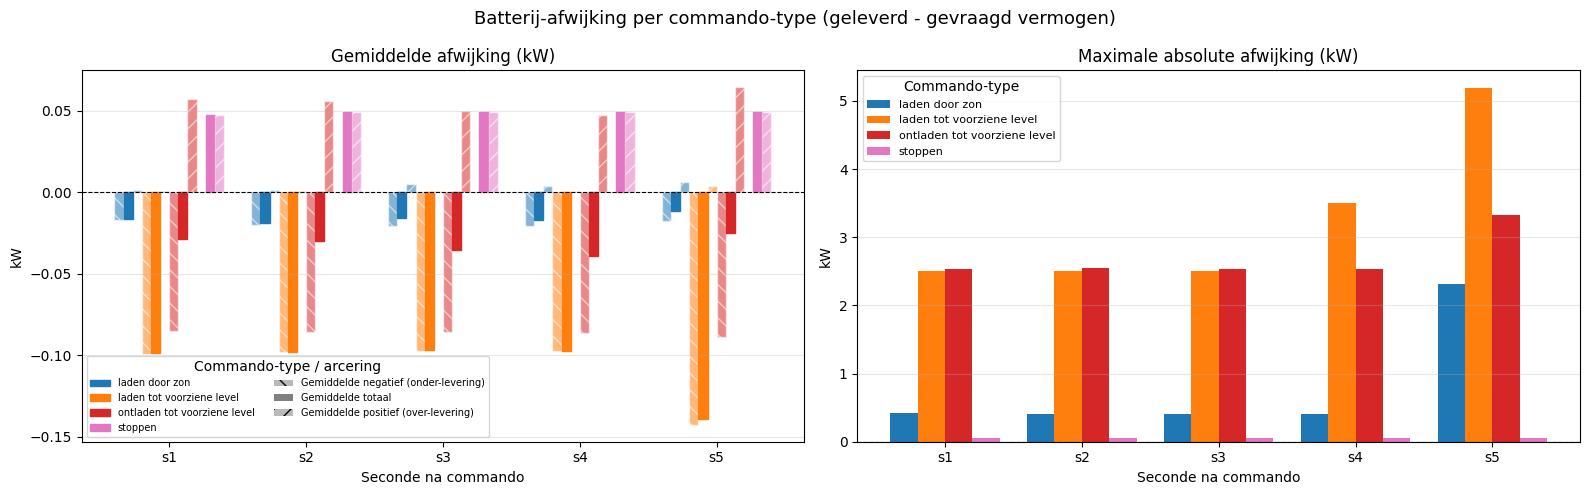

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# ── Unieke acties en seconden ─────────────────────────────────────────────
acties   = df_afw["sofar_action"].unique()
seconden = sorted(df_afw["seconde"].unique())   # [1, 2, 3, 4, 5]
n_acties = len(acties)

# ── Kleurpalet: één kleur per actie-type ──────────────────────────────────
kleuren = plt.cm.tab10(np.linspace(0, 0.6, n_acties))

# ── Drie bar-types op het linker paneel ───────────────────────────────────
# De grafiek toont per seconde voor elke actie drie balken naast elkaar:
#
#   gem_negatief  (gearceerd \)  gemiddelde van alle afwijkingen < 0
#                                 → meet hoe groot de onder-levering is
#   gem_afwijking (vol)           gemiddelde over ALLE afwijkingen (+ en -)
#                                 → geeft de netto systematische fout
#   gem_positief  (gearceerd /)   gemiddelde van alle afwijkingen > 0
#                                 → meet hoe groot de over-levering is
#
# Als gem_negatief en gem_positief ongeveer even groot zijn maar tegengesteld
# van teken, heffen ze elkaar op in gem_afwijking -> gem_afwijking nul, maar
# de spreiding is groot. Als gem_afwijking != 0 is er een systematische fout.

TYPES = [
    ("gem_negatief", "\\\\", 0.55, "neg"),   # hatch, alpha, suffix legenda
    ("gem_afwijking", "",   1.0,  "gem"),
    ("gem_positief", "//",  0.55, "pos"),
]
n_types  = len(TYPES)
breedte  = 0.8 / (n_acties * n_types)
x        = np.arange(len(seconden))

fig, assen = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
fig.suptitle("Batterij-afwijking per commando-type (geleverd - gevraagd vermogen)", fontsize=13)

for i, actie in enumerate(acties):
    sub = df_afw[df_afw["sofar_action"] == actie].set_index("seconde")

    for j, (kolom, hatch, alpha, suffix) in enumerate(TYPES):
        waarden = [sub.loc[s, kolom] if s in sub.index else 0 for s in seconden]
        # Offset: elke actie heeft n_types balken; binnen de actie-groep
        # staan de 3 types aaneengesloten.
        totale_idx = i * n_types + j
        offset     = (totale_idx - (n_acties * n_types) / 2 + 0.5) * breedte

        # Enkel de gem_afwijking-balk krijgt een label in de legenda.
        label = actie if suffix == "gem" else "_nolegend_"
        assen[0].bar(
            x + offset, waarden, width=breedte,
            label=label, color=kleuren[i], hatch=hatch, alpha=alpha,
            edgecolor="white" if hatch else kleuren[i],
        )

# ── Rechter paneel: maximale absolute afwijking (ongewijzigd) ─────────────
breedte_r = 0.8 / n_acties
for i, actie in enumerate(acties):
    sub = df_afw[df_afw["sofar_action"] == actie].set_index("seconde")
    mx  = [sub.loc[s, "max_afwijking"] if s in sub.index else 0 for s in seconden]
    offset = (i - n_acties / 2 + 0.5) * breedte_r
    assen[1].bar(x + offset, mx, width=breedte_r, label=actie, color=kleuren[i])

# ── Legenda-uitleg voor de arceringen (alleen op linker paneel) ───────────
from matplotlib.patches import Patch
legenda_types = [
    Patch(facecolor="grey", hatch="\\\\", alpha=0.55, label="Gemiddelde negatief (onder-levering)"),
    Patch(facecolor="grey", hatch="",   alpha=1.0,  label="Gemiddelde totaal"),
    Patch(facecolor="grey", hatch="//",  alpha=0.55, label="Gemiddelde positief (over-levering)"),
]

# ── Assen opmaken ─────────────────────────────────────────────────────────
titels  = ["Gemiddelde afwijking (kW)", "Maximale absolute afwijking (kW)"]
for ax, titel in zip(assen, titels):
    ax.set_title(titel)
    ax.set_xlabel("Seconde na commando")
    ax.set_ylabel("kW")
    ax.set_xticks(x)
    ax.set_xticklabels([f"s{s}" for s in seconden])
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.grid(axis="y", alpha=0.3)

# Actielegende op rechter paneel; type-legende onderaan linker paneel
assen[1].legend(fontsize=8, title="Commando-type")
handles, labels = assen[0].get_legend_handles_labels()
assen[0].legend(
    handles + legenda_types,
    labels  + [p.get_label() for p in legenda_types],
    fontsize=7, ncol=2, title="Commando-type / arcering",
)

plt.tight_layout()
plt.show()

## 5. Outliers in de afwijking

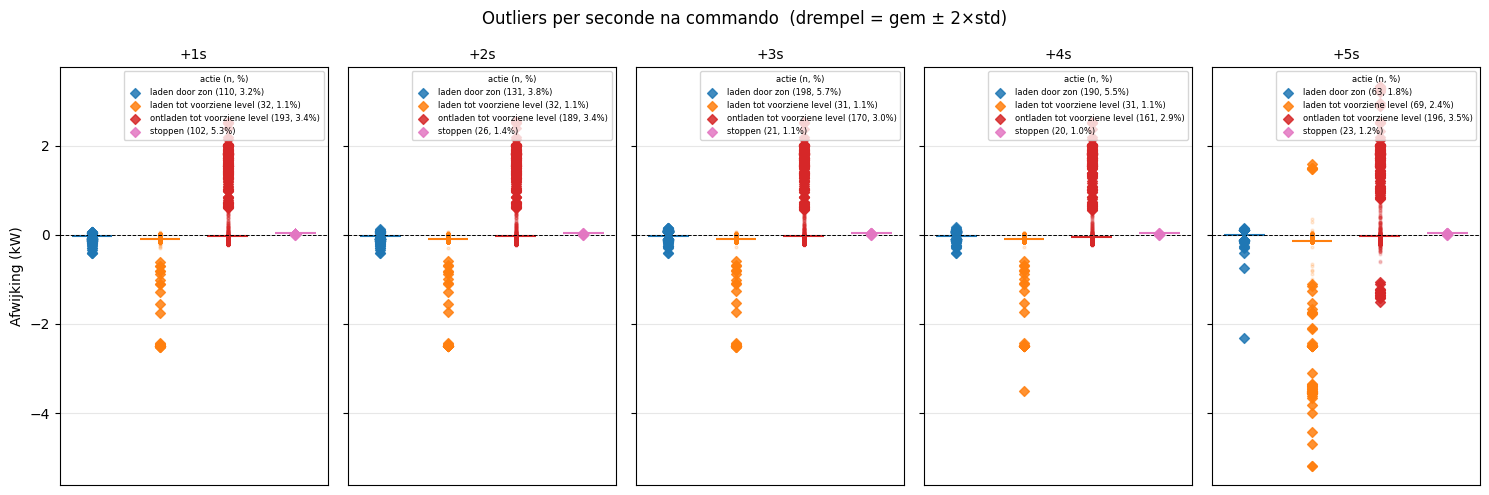


Outlier-rapport (drempel = 2×std):

                sofar_action  seconde  n_totaal  n_outliers  pct_outliers     gem    std  drempel
              laden door zon        1      3454         110           3.2 -0.0163 0.0287   0.0575
              laden door zon        2      3454         131           3.8 -0.0187 0.0298   0.0596
              laden door zon        3      3454         198           5.7 -0.0160 0.0344   0.0688
              laden door zon        4      3454         190           5.5 -0.0169 0.0325   0.0649
              laden door zon        5      3454          63           1.8 -0.0118 0.0527   0.1053
   laden tot voorziene level        1      2867          32           1.1 -0.0989 0.2155   0.4311
   laden tot voorziene level        2      2867          32           1.1 -0.0978 0.2151   0.4302
   laden tot voorziene level        3      2867          31           1.1 -0.0970 0.2102   0.4203
   laden tot voorziene level        4      2867          31           1.1 -0.0972

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════
# PARAMETERS
# ══════════════════════════════════════════════════════════════════════════
# DREMPEL_FACTOR bepaalt hoe ver een punt van het gemiddelde moet afwijken
# om als outlier beschouwd te worden.
# Formule: |afwijking − gemiddelde| > DREMPEL_FACTOR × standaardafwijking
# Waarde 2 = ~5% kans bij een normaalverdeling → streng maar gangbaar
DREMPEL_FACTOR = 2

# Lijst van de 5 afwijkingskolommen (één per seconde na het commando)
afw_kolommen = [f"afwijking_kw_s{n}" for n in range(1, 6)]

# Gesorteerde lijst van alle acties voor een vaste kleur-actie-koppeling
acties_gesorteerd = sorted(df_respons["sofar_action"].dropna().unique())

# Bouw een woordenboek {actie: kleur} zodat elke actie in alle deelvensters
# dezelfde kleur heeft en de legende consistent is
kleur_map = dict(zip(
    acties_gesorteerd,
    plt.cm.tab10(np.linspace(0, 0.6, len(acties_gesorteerd)))
))

# ══════════════════════════════════════════════════════════════════════════
# OUTLIER-STATISTIEKEN BEREKENEN
# ══════════════════════════════════════════════════════════════════════════
# Voor elke combinatie van seconde × actie:
#   1. Haal alle afwijkingswaarden op (NaN verwijderd)
#   2. Bereken gemiddelde en standaardafwijking
#   3. Markeer punten buiten gem ± DREMPEL_FACTOR×std als outlier
#   4. Sla statistieken + ruwe waarden op voor plot én tabel
rapport = []
for kol in afw_kolommen:
    seconde = int(kol.split("_s")[1])          # "afwijking_kw_s3" → 3
    data    = df_respons[["sofar_action", kol]].dropna()

    for actie, groep in data.groupby("sofar_action"):
        waarden = groep[kol].values
        gem     = waarden.mean()
        std     = waarden.std()

        # Boolean masker: True voor outliers
        is_out = np.abs(waarden - gem) > DREMPEL_FACTOR * std
        n_out  = int(is_out.sum())

        rapport.append({
            "seconde":      seconde,
            "sofar_action": actie,
            "n_totaal":     len(waarden),
            "n_outliers":   n_out,
            "pct_outliers": round(100 * n_out / len(waarden), 1),
            "gem":          round(gem, 4),
            "std":          round(std, 4),
            "drempel":      round(DREMPEL_FACTOR * std, 4),
            # Ruwe arrays bewaard voor de strip-plot hieronder
            "_waarden":     waarden,
            "_is_out":      is_out,
        })

df_rapport = pd.DataFrame(rapport)

# ══════════════════════════════════════════════════════════════════════════
# STRIP-PLOT: één deelvenster per seconde
# ══════════════════════════════════════════════════════════════════════════
# Elke kolom = één seconde. Binnen een kolom staan de 4 actie-types naast
# elkaar als verticale puntenwolken. sharey=True zodat de y-schaal gelijk
# blijft over alle seconden en vergelijking mogelijk is.
fig, assen = plt.subplots(1, len(afw_kolommen), figsize=(15, 5), sharey=True)
fig.suptitle(
    f"Outliers per seconde na commando  (drempel = gem ± {DREMPEL_FACTOR}×std)",
    fontsize=12,
)

for ax, kol in zip(assen, afw_kolommen):
    seconde = int(kol.split("_s")[1])
    rijen   = df_rapport[df_rapport["seconde"] == seconde]
    x_pos   = 0   # elke actie krijgt een eigen x-positie binnen het deelvenster

    for _, r in rijen.iterrows():
        kleur   = kleur_map[r["sofar_action"]]
        normaal = r["_waarden"][~r["_is_out"]]   # gewone punten
        uitbijt = r["_waarden"][ r["_is_out"]]   # outliers

        # Normale metingen: kleine, transparante punten
        # Door de lage alpha smelten overlappende punten samen tot een "wolk";
        # hoe dichter de punten op elkaar liggen, hoe donkerder de wolk wordt.
        # De visuele dikte van de wolk weerspiegelt dus de dichtheid van de verdeling.
        ax.scatter([x_pos] * len(normaal), normaal,
                   s=4, alpha=0.15, color=kleur)

        # Outliers: grotere diamanten, goed zichtbaar bovenop de wolk (zorder=5)
        # In de legenda: naam van de actie + (aantal, percentage) voor snelle lezing
        if len(uitbijt):
            ax.scatter([x_pos] * len(uitbijt), uitbijt,
                       s=25, alpha=0.85, color=kleur, marker="D", zorder=5,
                       label=f"{r['sofar_action']} ({r['n_outliers']}, {r['pct_outliers']}%)")

        # Horizontale lijn op het gemiddelde van deze actie in dit deelvenster.
        # De lijndikte (linewidth=1.5) is voor alle acties gelijk; de positie
        # op de y-as laat zien of het gemiddelde boven of onder nul ligt.
        ax.hlines(r["gem"], x_pos - 0.3, x_pos + 0.3,
                  colors=kleur, linewidth=1.5)

        x_pos += 1   # volgende actie naast de vorige

    # Stippellijn op y=0: dit is het ideaal (batterij doet exact wat gevraagd)
    ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
    ax.set_title(f"+{seconde}s", fontsize=10)
    ax.set_xticks([])   # x-as heeft geen labels – actie-namen staan in de legenda
    ax.grid(axis="y", alpha=0.3)

    # Legenda alleen tonen als er outliers zijn (anders is ze leeg)
    if ax.get_legend_handles_labels()[0]:
        ax.legend(fontsize=6, loc="upper right",
                  title="actie (n, %)", title_fontsize=6)

assen[0].set_ylabel("Afwijking (kW)")
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# OVERZICHTSTABEL
# ══════════════════════════════════════════════════════════════════════════
# Sorteren op actie + seconde voor een leesbare tabel.
# n_outliers en pct_outliers geven snel inzicht in hoe vaak extreme
# afwijkingen voorkomen bij elk commando-type en elke seconde.
print(f"\nOutlier-rapport (drempel = {DREMPEL_FACTOR}×std):\n")
print(
    df_rapport[["sofar_action", "seconde", "n_totaal", "n_outliers",
                "pct_outliers", "gem", "std", "drempel"]]
    .sort_values(["sofar_action", "seconde"])
    .to_string(index=False)
)

### Uitleg van de grafiek

**Structuur**
De grafiek bestaat uit 5 deelvensters, één per seconde na het commando (+1s t/m +5s). Binnen elk venster staan de 4 commando-types naast elkaar op de x-as. De y-as toont de afwijking in kW (positief = batterij levert meer dan gevraagd, negatief = batterij levert minder).

---

**Betekenis van de visuele elementen**

| Element | Wat het is | Wat het betekent |
|---|---|---|
| **Kleine ronde punten** | Alle individuele metingen (normaal) | Elke punt is één commando-moment. De kleur geeft het commando-type aan. |
| **Dikte van de puntenwolk** | Concentratie van waarden | Hoe dikker de wolk, hoe meer metingen op die waarde clusteren. Een smalle wolk duidt op een consistente, voorspelbare respons; een brede wolk wijst op grote variatie. |
| **Diamanten (◆)** | Outliers | Punten waarvoor \|afwijking − gemiddelde\| > 2 × standaardafwijking. Ze liggen duidelijk buiten de normale spreiding. Tussen haakjes staat het aantal en het percentage. |
| **Horizontale streep (—)** | Gemiddelde afwijking | De dikte van de streep (1.5 pt) is voor alle acties gelijk; alleen de positie op de y-as verschilt. Een streep precies op 0 betekent dat de batterij gemiddeld exact het gevraagde vermogen levert. |

---

**Analyse per commando-type**

**`stoppen`**
De puntenwolk zit uiterst smal gebundeld net boven 0 (≈ +0.05 kW). Dat kleine positieve gemiddelde is een restant van de minimale batterijstroom die de SOFAR-omvormer altijd trekt bij "stoppen". Er zijn vrijwel geen outliers. De batterij reageert op dit commando vrijwel onmiddellijk en met hoge herhaalnauwkeurigheid — het gedrag is over alle 5 seconden identiek.

**`laden door zon`**
De wolk is iets breder dan bij stoppen, maar blijft geconcentreerd rond een kleine negatieve afwijking (≈ −0.02 kW). Dit commando wordt gestuurd op basis van de actuele PV-productie en varieert dus in grootte; toch is de spreiding gering. Enkele schaarse outliers zijn zichtbaar, maar hun percentage blijft laag. Het systeem volgt dit commando goed op over alle 5 seconden.

**`ontladen tot voorziene level`**
De wolk is merkbaar breder: de batterij ontlaadt niet altijd exact het gevraagde vermogen, maar wijkt gemiddeld slechts licht af (≈ −0.03 kW). De outliers zijn iets talrijker dan bij laden door zon, maar de gemiddelde streep blijft stabiel over de 5 seconden — er is geen toenemende afwijking naarmate de tijd vordert. De spreiding is vermoedelijk deels te verklaren door variatie in het netverbruik op het moment van het commando.

**`laden tot voorziene level`**
Dit type vertoont de breedste puntenwolk én de meeste uitschieters. Het gemiddelde is stelselmatig negatief (≈ −0.10 kW) en de maximale outliers groeien toe naar s5 (tot > 5 kW). De verklaring is dat dit commando wordt afgegeven wanneer de batterij een vooraf bepaald laadvermogen moet aanhouden; op het moment dat het doelvermogen bereikt is, schakelt de regelaar terug en ontstaat een korte piek in de afwijking. De outliers bij s4–s5 zijn dan ook geen aanloopfout maar een afsluiteffect: de regelaar is aan het terugschakelen terwijl de meting nog de overgangswaarde registreert.

---

**Besluit**

De batterij volgt de meeste commando's binnen enkele honderdsten kW nauwkeurig op. De kleine maar consistente negatieve afwijking over alle commando-types en seconden wijst op een vaste kalibratieafwijking in de SOFAR-regelaar — niet op een trage of verslechterende respons in de tijd.

De grootste onnauwkeurigheid doet zich voor bij `laden tot voorziene level`, specifiek aan het einde van de responstijd (s4–s5). Dit is inherent aan het regelgedrag bij het bereiken van het doelvermogen en is geen teken van een defect.

> **Aanbeveling:** de systematische offset (0.05–0.10 kW) is verwaarloosbaar voor analyses op dagtotaalniveau. Voor vermogenssturing op secondeniveau — bijvoorbeeld om pieken te vermijden — is een correctiefactor in de commando-berekening zinvol.

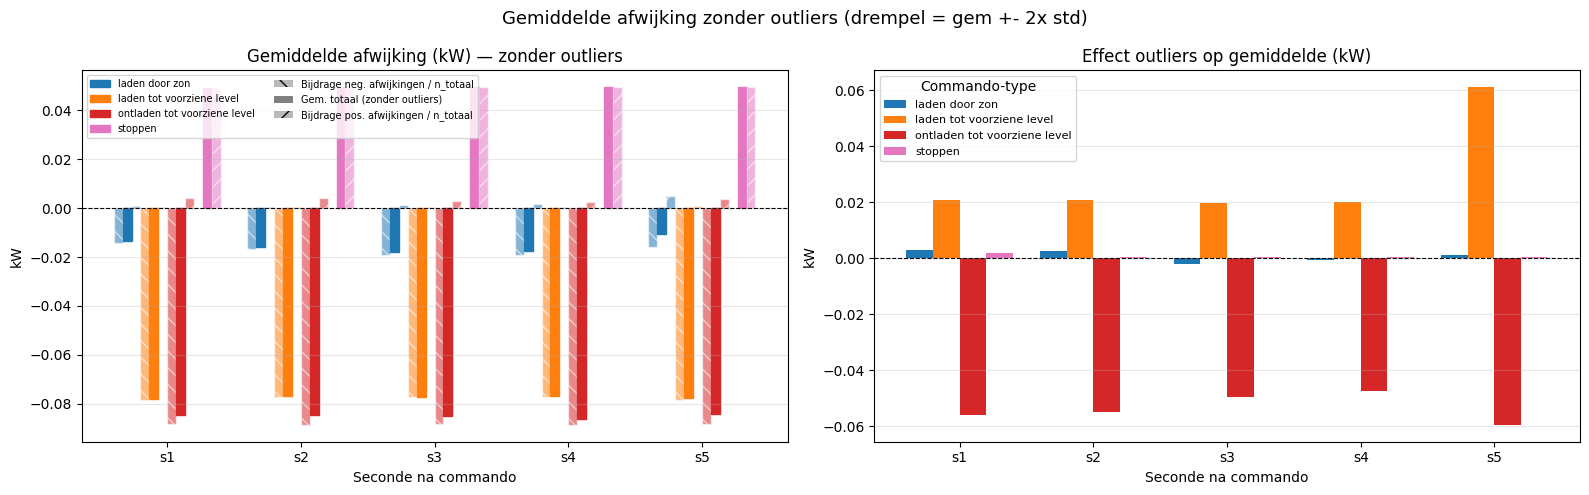

Vergelijking gemiddelde MET vs ZONDER outliers (drempel = 2x std):

                sofar_action  seconde  gem_met  gem_zonder  verschil  n_verwijderd
              laden door zon        1  -0.0163     -0.0135    0.0028           110
              laden door zon        2  -0.0187     -0.0161    0.0026           131
              laden door zon        3  -0.0160     -0.0179   -0.0019           198
              laden door zon        4  -0.0169     -0.0175   -0.0006           190
              laden door zon        5  -0.0118     -0.0107    0.0011            63
   laden tot voorziene level        1  -0.0989     -0.0780    0.0209            32
   laden tot voorziene level        2  -0.0978     -0.0770    0.0208            32
   laden tot voorziene level        3  -0.0970     -0.0771    0.0199            31
   laden tot voorziene level        4  -0.0972     -0.0770    0.0202            31
   laden tot voorziene level        5  -0.1389     -0.0778    0.0611            69
ontladen tot voorzi

In [31]:
# ══════════════════════════════════════════════════════════════════════════
# GEMIDDELDEN ZONDER OUTLIERS
# ══════════════════════════════════════════════════════════════════════════
# df_rapport bevat per (sofar_action, seconde) de ruwe waarden (_waarden)
# en het outlier-masker (_is_out) dat in de vorige cel berekend werd.
#
# gem_positief en gem_negatief worden berekend als gewogen bijdragen
# ten opzichte van het TOTAAL aantal gekuiste metingen (niet enkel de
# positieve of negatieve subset). Zo geldt: gem_pos + gem_neg = gem_zonder.

rijen_clean = []
for _, r in df_rapport.iterrows():
    vals  = r["_waarden"][~r["_is_out"]]   # verwijder outliers
    n_tot = len(vals)
    if n_tot == 0:
        continue
    som_pos = vals[vals > 0].sum()
    som_neg = vals[vals < 0].sum()
    rijen_clean.append({
        "sofar_action":    r["sofar_action"],
        "seconde":         r["seconde"],
        "gem_zonder":      round(float(vals.mean()), 4),
        "gem_pos_zonder":  round(som_pos / n_tot, 4),   # gewogen bijdrage positieven
        "gem_neg_zonder":  round(som_neg / n_tot, 4),   # gewogen bijdrage negatieven
        "gem_met":         r["gem"],                    # ter vergelijking: met outliers
        "verschil":        round(float(vals.mean()) - r["gem"], 4),
        "n_clean":         int(n_tot),
        "n_verwijderd":    int(r["n_outliers"]),
    })

df_clean_afw = pd.DataFrame(rijen_clean)

# ── Grafiek: zelfde opbouw als sectie 4 maar op gekuiste data ─────────────
acties_c   = df_clean_afw["sofar_action"].unique()
seconden_c = sorted(df_clean_afw["seconde"].unique())
n_acties_c = len(acties_c)
kleuren_c  = plt.cm.tab10(np.linspace(0, 0.6, n_acties_c))

TYPES_C = [
    ("gem_neg_zonder", "\\\\", 0.55),
    ("gem_zonder",     "",   1.0),
    ("gem_pos_zonder", "//",  0.55),
]
n_types_c = len(TYPES_C)
breedte_c = 0.8 / (n_acties_c * n_types_c)
x_c       = np.arange(len(seconden_c))

fig, assen_c = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    f"Gemiddelde afwijking zonder outliers (drempel = gem +- {DREMPEL_FACTOR}x std)",
    fontsize=13,
)

for i, actie in enumerate(acties_c):
    sub = df_clean_afw[df_clean_afw["sofar_action"] == actie].set_index("seconde")

    # Linker paneel: neg/totaal/pos bijdragen zonder outliers
    for j, (kol, hatch, alpha) in enumerate(TYPES_C):
        waarden    = [sub.loc[s, kol] if s in sub.index else 0 for s in seconden_c]
        totale_idx = i * n_types_c + j
        offset     = (totale_idx - (n_acties_c * n_types_c) / 2 + 0.5) * breedte_c
        label = actie if kol == "gem_zonder" else "_nolegend_"
        assen_c[0].bar(
            x_c + offset, waarden, width=breedte_c,
            label=label, color=kleuren_c[i], hatch=hatch, alpha=alpha,
            edgecolor="white" if hatch else kleuren_c[i],
        )

    # Rechter paneel: effect = gem_zonder - gem_met
    # Positief verschil: outliers trokken het gemiddelde omlaag
    # Negatief verschil: outliers trokken het gemiddelde omhoog
    verschil = [sub.loc[s, "verschil"] if s in sub.index else 0 for s in seconden_c]
    offset_r = (i - n_acties_c / 2 + 0.5) * (0.8 / n_acties_c)
    assen_c[1].bar(x_c + offset_r, verschil, width=0.8 / n_acties_c,
                   label=actie, color=kleuren_c[i])

# ── Legenda-arceringen ─────────────────────────────────────────────────────
from matplotlib.patches import Patch
legenda_types = [
    Patch(facecolor="grey", hatch="\\\\", alpha=0.55, label="Bijdrage neg. afwijkingen / n_totaal"),
    Patch(facecolor="grey", hatch="",   alpha=1.0,  label="Gem. totaal (zonder outliers)"),
    Patch(facecolor="grey", hatch="//",  alpha=0.55, label="Bijdrage pos. afwijkingen / n_totaal"),
]

# ── Assen opmaken ─────────────────────────────────────────────────────────
assen_c[0].set_title("Gemiddelde afwijking (kW) — zonder outliers")
assen_c[1].set_title("Effect outliers op gemiddelde (kW)")
for ax in assen_c:
    ax.set_xlabel("Seconde na commando")
    ax.set_ylabel("kW")
    ax.set_xticks(x_c)
    ax.set_xticklabels([f"s{s}" for s in seconden_c])
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.grid(axis="y", alpha=0.3)

assen_c[1].legend(fontsize=8, title="Commando-type")
handles_c, labels_c = assen_c[0].get_legend_handles_labels()
assen_c[0].legend(
    handles_c + legenda_types,
    labels_c  + [p.get_label() for p in legenda_types],
    fontsize=7, ncol=2,
)

plt.tight_layout()
plt.show()

# ── Vergelijkingstabel ─────────────────────────────────────────────────────
print(f"Vergelijking gemiddelde MET vs ZONDER outliers (drempel = {DREMPEL_FACTOR}x std):\n")
print(
    df_clean_afw[["sofar_action", "seconde", "gem_met", "gem_zonder", "verschil", "n_verwijderd"]]
    .sort_values(["sofar_action", "seconde"])
    .to_string(index=False)
)